## Import modules and dependencies

In [3]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [4]:
import sys
sys.path.append('Data')


In [5]:
convert_tcl = 'no'

In [6]:
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='sseven_five_nine.tcl',
                output_file='sseven_five_nine.py',
                prefix="ops")

## Basic Units

### Defaults  Units

In [7]:
# THESE ARE DEFAULT UNITS OF OPENSEES
mm = 1.0 # Meters
N = 1.0 # KiloNewtons
sec = 1.0 # Seconds

## Define Material Properties

### Steel Material

In [8]:
#Common Material Steel
Es = 210000# initial elastic tangent
Fy_s355 = 355 #Mpa
Fy_s275 = 275 #Mpa
Fy_s400 = 400 #Mpa
Steel_strain_hardng = 0.01 # Steel strain hardening
vs = 0.2
Gs = Es / (2 * (1 + vs))
# PLATE MATERIAL PROPERTIES:
FyP = 2400			# Steel plate yield stress
CyP = 0.02			# Steel plate yield strain
EsP = FyP/CyP	    # modulus of steel
BsP = 0.01			# strain-hardening ratio 
R0P = 18.0			# control the transition from elastic to plastic branches
cR1P = 0.925		# control the transition from elastic to plastic branches
cR2P = 0.15			# control the transition from elastic to plastic branches
# REBAR MATERIAL PROPERTIES:
Fy_reinf = 400			# Steel rebar yield stress
Cy = 0.02			# Steel rebar yield strain
Es_reinf = Fy_reinf/Cy			# modulus of steel
Bs = 0.01			# strain-hardening ratio 
R0 = 18.0			# control the transition from elastic to plastic branches
cR1 = 0.925			# control the transition from elastic to plastic branches
cR2 = 0.15			# control the transition from elastic to plastic branches

### Concrete Material

In [9]:
fck = 40 #[N/mm^2] 
fcm = fck + 8  # [N/mm^2] Concrete Compressive Strength (+Tension, -Compression)
# nominal concrete compressive strength
Ecm = 22000 * (fcm / 10)**0.3 # [N/mm^2] Concrete Elastic Modulus
vs = 0.2
Gc = Ecm / (2 * (1 + vs))
# confined concrete
Kfc = 1.3;			# ratio of confined to unconfined concrete strength
fc1C = Kfc*fcm;		# CONFINED concrete (mander model), maximum stress
eps1C = 2*fc1C/Ecm;	# strain at maximum stress 
fc2C = 0.2*fc1C;	# ultimate stress
eps2C = 5*eps1C;	# strain at ultimate stress 
# unconfined concrete
fc1U = fcm;			# UNCONFINED concrete (todeschini parabolic model), maximum stress
eps1U = -0.0025;	# strain at maximum strength of unconfined concrete
fc2U = 0.2*fc1U;	# ultimate stress
eps2U = -0.012;		# strain at ultimate stress
Lambda = 0.1;		# ratio between unloading slope at $eps2 and initial slope $Ec
# tensile-strength properties
ftC = -0.55*fc1C;	# tensile strength +tension
ftU = -0.55*fc1U;	# tensile strength +tension
Ets = ftU/0.002;	# tension softening stiffness

### Soil Material

In [10]:
# Define constants
E = 2.1e11       # Elastic modulus of the foundation material (Pa)
H = 0.5          # Height (thickness) of the foundation (m)
B = 5.0          # Width of the foundation (m)
L = 10.0         # Length of the foundation (m)
K = 1e8          # Modulus of subgrade (soil spring stiffness) reaction (Pa/m)
P = -1e6         # Compression force applied at the center of the foundation (N)

# Derived properties
nu = 0.3         # Poisson's ratio for the foundation material
rho = 2500       # Density of the foundation material (kg/m^3)

## Framing and Fixities

In [11]:
t = H            # Thickness of the shell elements

# Derived properties
I = B * H**3 / 12  # Moment of inertia for the rectangular cross-section (m^4)

# Discretization
nx = 50  # Number of grid points along length
ny = 25  # Number of grid points along width
dx = L / (nx - 1)
dy = B / (ny - 1)

In [12]:
nodes = nx * ny  # Total number of nodes
A = np.zeros((nodes, nodes))  # Coefficient matrix
b = np.zeros(nodes)          # Right-hand side vector

# Helper functions for indexing in 2D
index = lambda i, j: i * ny + j

# Populate finite difference matrix
for i in range(1, nx - 1):
    for j in range(1, ny - 1):
        idx = index(i, j)

        # Contributions from bending in x-direction
        A[idx, index(i - 1, j)] += E * I / dx**4
        A[idx, index(i + 1, j)] += E * I / dx**4
        A[idx, idx] -= 2 * E * I / dx**4

        # Contributions from bending in y-direction
        A[idx, index(i, j - 1)] += E * I / dy**4
        A[idx, index(i, j + 1)] += E * I / dy**4
        A[idx, idx] -= 2 * E * I / dy**4

        # Soil spring contribution
        A[idx, idx] += K

# Apply compression force at the center of the foundation
center_x, center_y = nx // 2, ny // 2
b[index(center_x, center_y)] -= P / (dx * dy)  # Convert force to pressure

# Boundary conditions (fixed edges: zero displacement)
for i in range(nx):
    for j in [0, ny - 1]:  # Fixed along y-edges
        A[index(i, j), index(i, j)] = 1
        b[index(i, j)] = 0
for j in range(ny):
    for i in [0, nx - 1]:  # Fixed along x-edges
        A[index(i, j), index(i, j)] = 1
        b[index(i, j)] = 0

# Solve for displacements
y_fd = np.linalg.solve(A, b).reshape((nx, ny))

# Calculate reactions (subgrade reaction)
reactions_fd = -K * y_fd

### Initialize

In [13]:
AnalysisType = "Static" #transient Static Pushover Cyclic Pushover Gravity
AnalysisType_step2 = "no" # yes or no

In [14]:
ops.wipe()
#nodes_dict = dict()

### Framing

In [15]:
ops.model('basic', '-ndm', 3, '-ndf', 6)

In [16]:
ops.uniaxialMaterial("ENT", 1, K)            # No Tension Soil
#ops.uniaxialMaterial("Elastic", 1, K)       # Soil
# Create nodes
node_tags = {}
spring_tags = {}
tag = 1
spring_tag = 1
NZ = 200000 # soil spring base node started 
for i in range(nx):
    for j in range(ny):
        x = i * dx
        y = j * dy
        node_tags[(i, j)] = tag
        ops.node(tag, x, y, 0.0)
        # Create a spring node directly below the foundation node
        spring_node = tag + nodes + NZ
        spring_tags[(i, j)] = spring_node
        ops.node(spring_node + NZ, x, y, 0.0)       # define base soil springs nodes
        ops.fix(spring_node + NZ, 1, 1, 1, 1, 1, 1) # fix base soil springs nodes
        # Create zero-length element for vertical spring
        ops.element("zeroLength", spring_node, spring_node + NZ, tag, "-mat", 1, "-dir", 3)
        spring_tag += 1
        tag += 1

# Define material and section
ops.nDMaterial("ElasticIsotropic", 1, E, nu, rho)
ops.section("PlateFiber", 1, 1, t)

# Create ShellMITC4 elements
tag = 1
element_tags = {}
for i in range(nx - 1):
    for j in range(ny - 1):
        node1 = node_tags[(i, j)]
        node2 = node_tags[(i + 1, j)]
        node3 = node_tags[(i + 1, j + 1)]
        node4 = node_tags[(i, j + 1)]
        ops.element("ShellMITC4", tag, node1, node2, node3, node4, 1)
        element_tags[(i, j)] = tag
        tag += 1

### Fixities

### Equal DOFs

### Define Rigid Diaphragms

In [17]:
opst.vis.plotly.plot_model()

OPSTOOL ::  Model data has been saved to _OPSTOOL_ODB/ModelData-None.nc!

## Define Tags

### Material Tags

In [18]:
#Material Tag for Fiber section
# matTagC = 1 # Concrete cover
# matTagCCore = 2 # Concrete core
# matTagS = 3 # Steel Reinforcement 
# matTagHardening = 4 # Hardening Steel

### Section Tags

## Define the sections

### Section Tags

### Uniaxial Material

### nDmaterials

### Fiber Section

### Elastic Section

### 

### Soil Material

## Define Transformation

### Transformation Tags

### Section aggregation

### geometeric transformation

### Beam Integration

## Assemble the Model

In [19]:
opst.vis.plotly.plot_model()

OPSTOOL ::  Model data has been saved to _OPSTOOL_ODB/ModelData-None.nc!

## Define Recorders

### Directory

In [20]:
dataDir = 'Data'
if not os.path.exists(dataDir):
    os.makedirs(dataDir)

# Define these variables before using them
OutputDirName = "seven_five_nine"  # Change this as needed
AnalysisName = "examp"  # Change this as needed

# Construct the base directory and filename
baseDir = os.path.join('outputs', OutputDirName)
baseName = os.path.join(baseDir, AnalysisName)

# Ensure the base directory exists
if not os.path.exists(baseDir):
    os.makedirs(baseDir)

print(f"Recorder output path: {baseName}")  # Debugging output

Recorder output path: outputs\seven_five_nine\examp


### Recorders

## Loadings and Analysis

### Analysis Parameters

### time series and patterns tags

In [21]:
# Apply distributed load
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)

center_tag = node_tags[(center_x, center_y)]
ops.load(center_tag, 0.0, 0.0, P, 0.0, 0.0, 0.0)

#### Time series tags

#### Pattern tags

### Define masses

### Gravity 

In [22]:
if(AnalysisType=="gravity_A"):

    # ------------------------------
    # Start of analysis generation
    # ------------------------------

    # Create the system of equation, a sparse solver with partial pivoting
    ops.system('BandGeneral')

    # Create the constraint handler, the transformation method
    ops.constraints('Plain')

    # Create the DOF numberer, the reverse Cuthill-McKee algorithm
    ops.numberer('Plain')

    # Create the convergence test, the norm of the residual with a tolerance of
    # 1e-12 and a max number of iterations of 10
    ops.test('EnergyIncr', 1.0e-6, 200)

    # Create the solution algorithm, a Newton-Raphson algorithm
    ops.algorithm('Newton')

    # Create the integration scheme, the LoadControl scheme using steps of 0.1
    ops.integrator('LoadControl', 1)

    # Create the analysis object
    ops.analysis('Static')

    # ------------------------------
    # End of analysis generation
    # ------------------------------


    # ------------------------------
    # Finally perform the analysis
    # ------------------------------

    # perform the gravity load analysis, requires 10 steps to reach the load level
    ops.analyze(1)

    # Print out the state of nodes 3 and 4
    # print node 3 4

    # Print out the state of element 1
    # print ele 1

### Gravity

In [23]:
if(AnalysisType=="gravity_B"):
    ops.constraints('Penalty', 1e+20, 1e+20)
    ops.numberer('RCM',)
    ops.system('UmfPack',)
    ops.test('NormDispIncr', 0.0001, 1000, 2)
    ops.algorithm('Linear',)
    ops.integrator('LoadControl', 0.07)
    ops.analysis('Static',)
    ops.analyze(1,)

### Static Analysis

In [24]:
if(AnalysisType=="Static"):
    
    print('analysis')
    ops.constraints('Transformation')
    ops.numberer('RCM')
    ops.system("BandGeneral")
    ops.integrator("LoadControl", 1.0)
    ops.algorithm("Linear")
    ops.analysis("Static")
    ops.analyze(1)
    # protocol=[1.0, 0, -1.0,-10]
    # analysis = opst.anlys.SmartAnalyze(analysis_type="Static")
    # segs = analysis.static_split(protocol, 1)
    # print(segs)
    # for seg in segs:
    #     analysis.StaticAnalyze(node=286, dof=3, seg=seg)  # node tag 1, dof 2

analysis


In [25]:
# Extract results
displacements = np.zeros((nx, ny))
reactions_os = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        disp = ops.nodeDisp(node_tags[(i, j)], 3)  # Z-direction displacement
        displacements[i, j] = disp
        reactions_os[i, j] = -K * disp

In [26]:
if(AnalysisType_step2=="yes"):
    ops.loadConst('-time', 0.0)
    ops.timeSeries('Linear', 2)
    ops.pattern('Plain', 2, 2)
    ops.load(5, 400000.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    ops.load(25, 400000.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    ops.load(4, 300000.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    ops.load(24, 300000.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    ops.load(3, 200000.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    ops.load(23, 200000.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    ops.load(2, 100000.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    ops.load(22, 100000.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    print('analysis')
    ops.constraints('Plain',)
    ops.numberer('Plain',)
    ops.system('BandGeneral',)
    # ops.test('EnergyIncr', 1e-06, 200)
    # ops.algorithm('Newton',)
    # ops.integrator('DisplacementControl', 25, 1, 4)
    # ops.analysis('Static',)
    # ops.analyze(50,)
    # ops.integrator('DisplacementControl', 25, 1, -8)
    # ops.analyze(50,)
    # ops.integrator('DisplacementControl', 25, 1, 12)
    # ops.analyze(50,)
    # ops.integrator('DisplacementControl', 25, 1, -16)
    # ops.analyze(50,)

    #protocol=[1,0,-10,-40,-80,-120,-400]
    protocol=[1,-400] #this value are the target displacement
    analysis = opst.anlys.SmartAnalyze(analysis_type="Static")
    segs = analysis.static_split(protocol, 2.0) #will the numner of steps 400/2.0 = 200 steps
    print(segs)
    for seg in segs:
        analysis.StaticAnalyze(node=25, dof=1, seg=seg)  # node tag 1, dof 2


### Pushover

In [27]:
if(AnalysisType=="Pushover"):
	
	print("<<<< Running Pushover Analysis >>>>")

	# create a plain load pattern for pushover analysis
	ops.pattern("Plain", 2, 1)
	
	ControlNode=53
	ControlDOF=1
	MaxDisp= 0.020
	DispIncr=0.00001
	NstepsPush=int(MaxDisp/DispIncr)
	
	ops.load(ControlNode, 1.00, 0.0, 0.0, 0.0, 0.0, 0.0)	# Apply a unit reference load in DOF=1
	
	ops.system("BandGeneral")
	ops.numberer("RCM")
	ops.constraints('Penalty',1e20,1e20)
	ops.integrator("DisplacementControl", ControlNode, ControlDOF, DispIncr)
	ops.algorithm('KrylovNewton')
	ops.test('NormDispIncr',1e-05, 1000, 2)
	ops.analysis("Static")
	
	# Create a folder to put the output
	PushDataDir = r'PushoverOut_shear'
	if not os.path.exists(PushDataDir):
		os.makedirs(PushDataDir)
	ops.recorder('Node', '-file', "PushoverOut/React.out", '-closeOnWrite', '-node', 1, 2, 3, 4, 5, '-dof',1, 'reaction')
	ops.recorder('Node', '-file', "PushoverOut/Disp.out", '-closeOnWrite', '-node', ControlNode, '-dof',1, 'disp')

	# Perform pushover analysis
	dataPush = np.zeros((NstepsPush+1,5))
	for j in range(NstepsPush):
		ops.analyze(1)
		dataPush[j+1,0] = ops.nodeDisp(ControlNode,1)*1000		# Convert to mm
		dataPush[j+1,1] = ops.getLoadFactor(2)*0.001			# Convert to kN
		
	# Read test output data to plot
	Test = np.loadtxt("Data/RCshearwall_TestOutput.txt", delimiter="\t", unpack="False")
	
	## Set parameters for the plot
	plt.rcParams.update({'font.size': 7})
	plt.figure(figsize=(4,3), dpi=100)
	plt.rc('font', family='serif')
	plt.plot(Test[0,:], Test[1,:], color="black", linewidth=0.8, linestyle="--", label='Test')
	plt.plot(dataPush[:,0], -dataPush[:,1], color="red", linewidth=1.2, linestyle="-", label='Pushover')
	plt.axhline(0, color='black', linewidth=0.4)
	plt.axvline(0, color='black', linewidth=0.4)
	plt.xlim(-25, 25)
	plt.xticks(np.linspace(-20,20,11,endpoint=True)) 
	plt.grid(linestyle='dotted') 
	plt.xlabel('Displacement (mm)')
	plt.ylabel('Base Shear (kN)')
	plt.legend()
	plt.savefig("PushoverOut_shear/RCshearwall_PushoverCurve.png",dpi=1200)
	plt.show()
	
	
	print("Pushover analysis complete")

### Cyclic

In [28]:
if(AnalysisType=="Cyclic"):
	
	# This is a load controlled analysis. The input load file "RCshearwall_Load_input.txt" should be in the 
	# .. same folder as the model file.
	
	print("<<<< Running Cyclic Analysis >>>>")
	
	ops.timeSeries('Path',2,'-dt',0.1,'-filePath','RCshearwall_Load_input.txt')
	ops.pattern('Plain',2,2)
	ops.sp(53,1,1)								# construct a single-point constraint object added to the LoadPattern.

	ops.constraints('Penalty',1e20,1e20)
	ops.numberer('RCM')
	ops.system('BandGeneral')
	ops.test('NormDispIncr',1e-05, 100, 1)
	ops.algorithm('KrylovNewton')
	ops.integrator('LoadControl',0.1)
	ops.analysis('Static')
	ops.analyze(700)

### Transient 

In [29]:
if(AnalysisType=="transient"):
    
    ops.constraints('Transformation')
    ops.numberer('Plain')
    ops.system('BandGeneral')
    #ops.integrator('Newmark', 0.5, 0.25)
    analysis = opst.anlys.SmartAnalyze(analysis_type="Transient")
    npts = 1000
    segs = analysis.transient_split(npts)
    for seg in segs:
        analysis.TransientAnalyze(dt)

### Dynamic Analysis

## Plots

### Plot Model

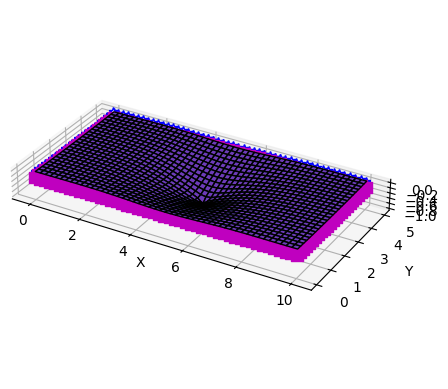

In [30]:
opsv.plot_defo()
ops.wipe()

### Plot force and deformation

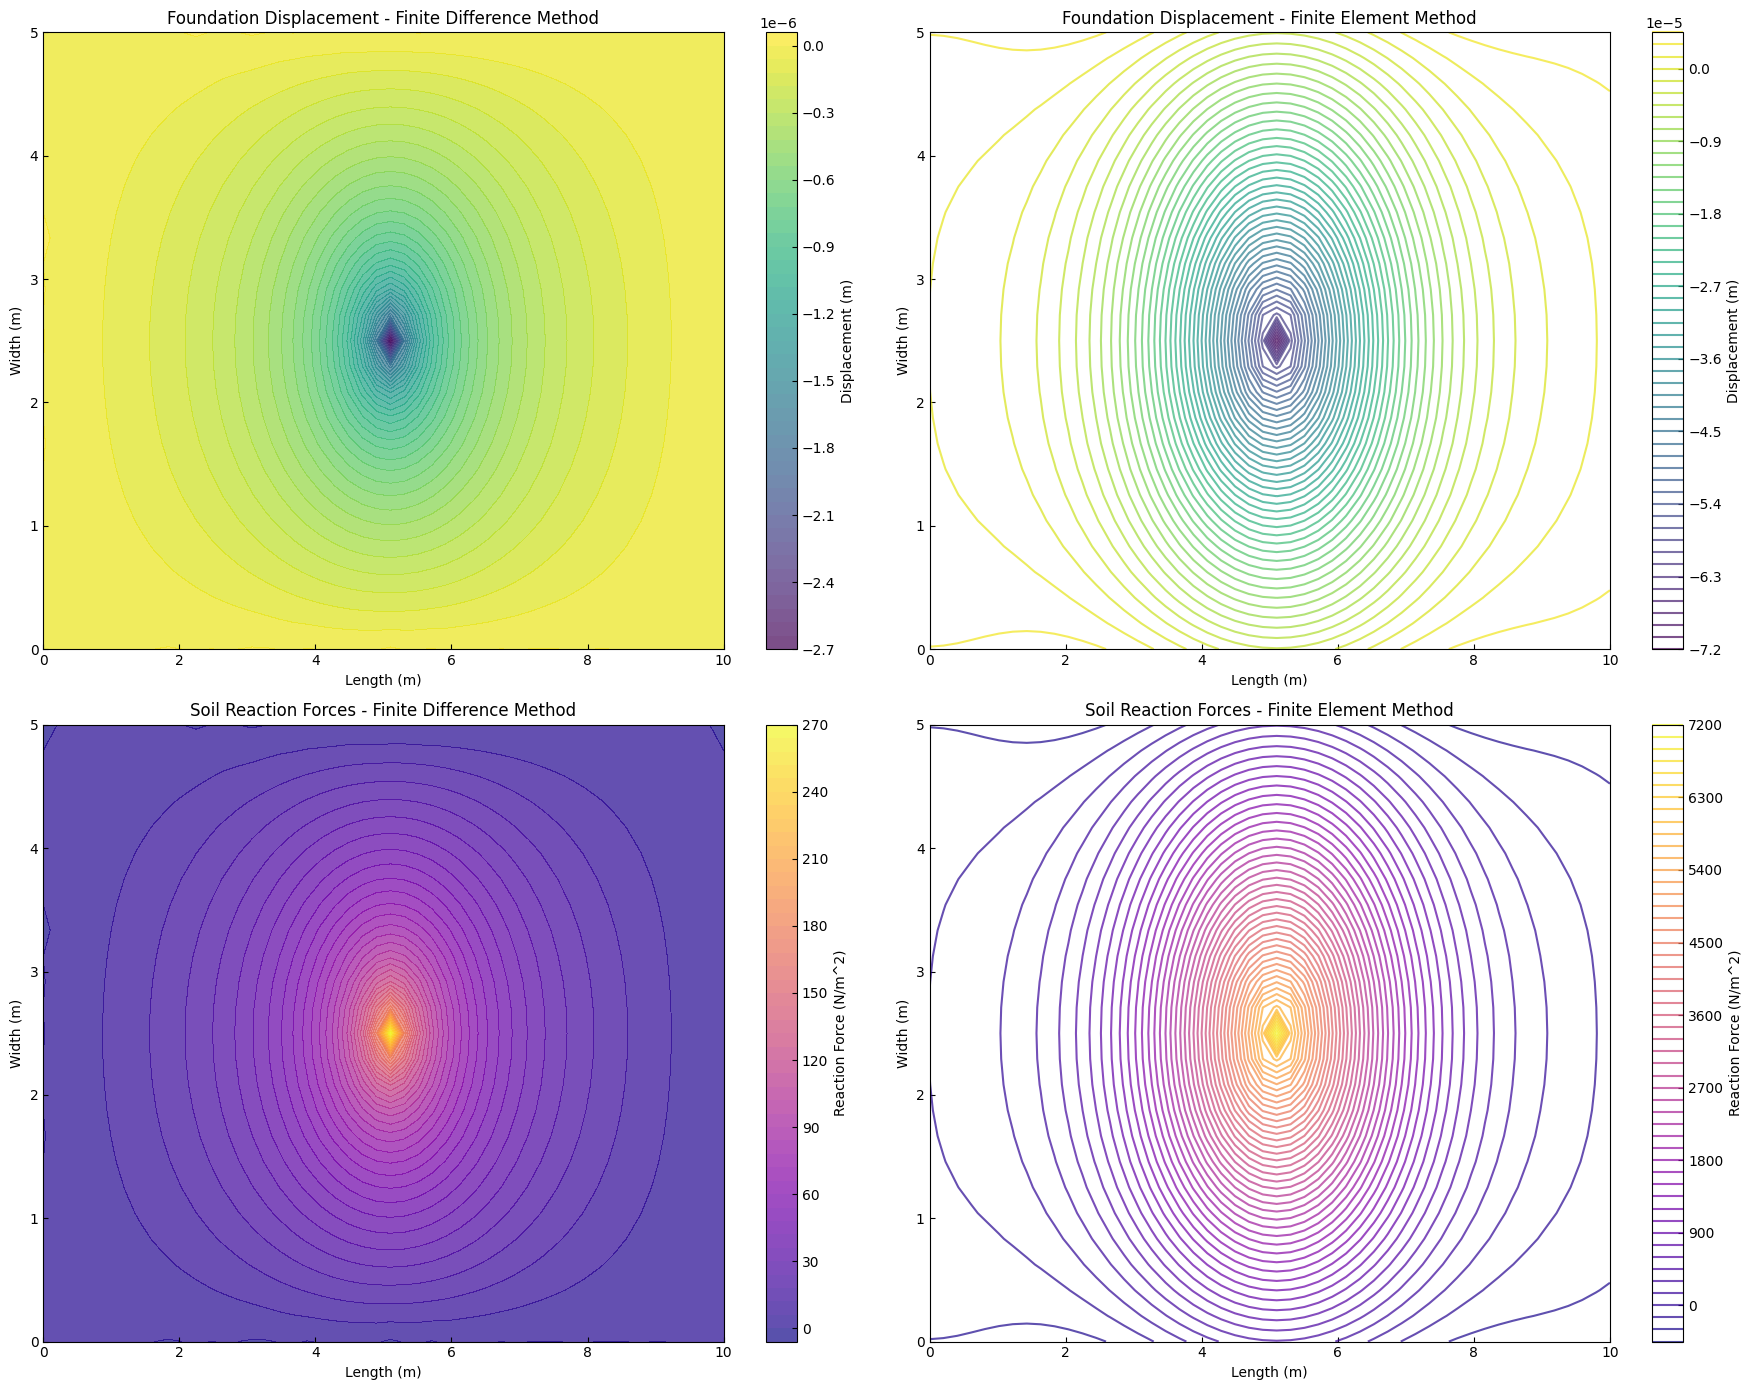

In [31]:
x = np.linspace(0, L, nx)
y_coords = np.linspace(0, B, ny)
X, Y = np.meshgrid(x, y_coords)

plt.figure(figsize=(18, 14))

# Plot displacement
plt.subplot(2, 2, 1)
plt.contourf(X, Y, y_fd.T, levels=50, cmap="viridis", alpha=0.7)
plt.colorbar(label="Displacement (m)")
plt.title("Foundation Displacement - Finite Difference Method")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")
plt.subplot(2, 2, 2)
plt.contour(X, Y, displacements.T, levels=50, cmap="viridis", alpha=0.7)  # , linestyles='--'
plt.colorbar(label="Displacement (m)")
plt.title("Foundation Displacement - Finite Element Method")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")

# Plot soil reactions
plt.subplot(2, 2, 3)
plt.contourf(X, Y, reactions_fd.T, levels=50, cmap="plasma", alpha=0.7)
plt.colorbar(label="Reaction Force (N/m^2)")
plt.title("Soil Reaction Forces - Finite Difference Method")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")
plt.subplot(2, 2, 4)
plt.contour(X, Y, reactions_os.T, levels=50, cmap="plasma", alpha=0.7)  # , linestyles='--'
plt.colorbar(label="Reaction Force (N/m^2)")
plt.title("Soil Reaction Forces - Finite Element Method")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")

plt.tight_layout()
plt.show()

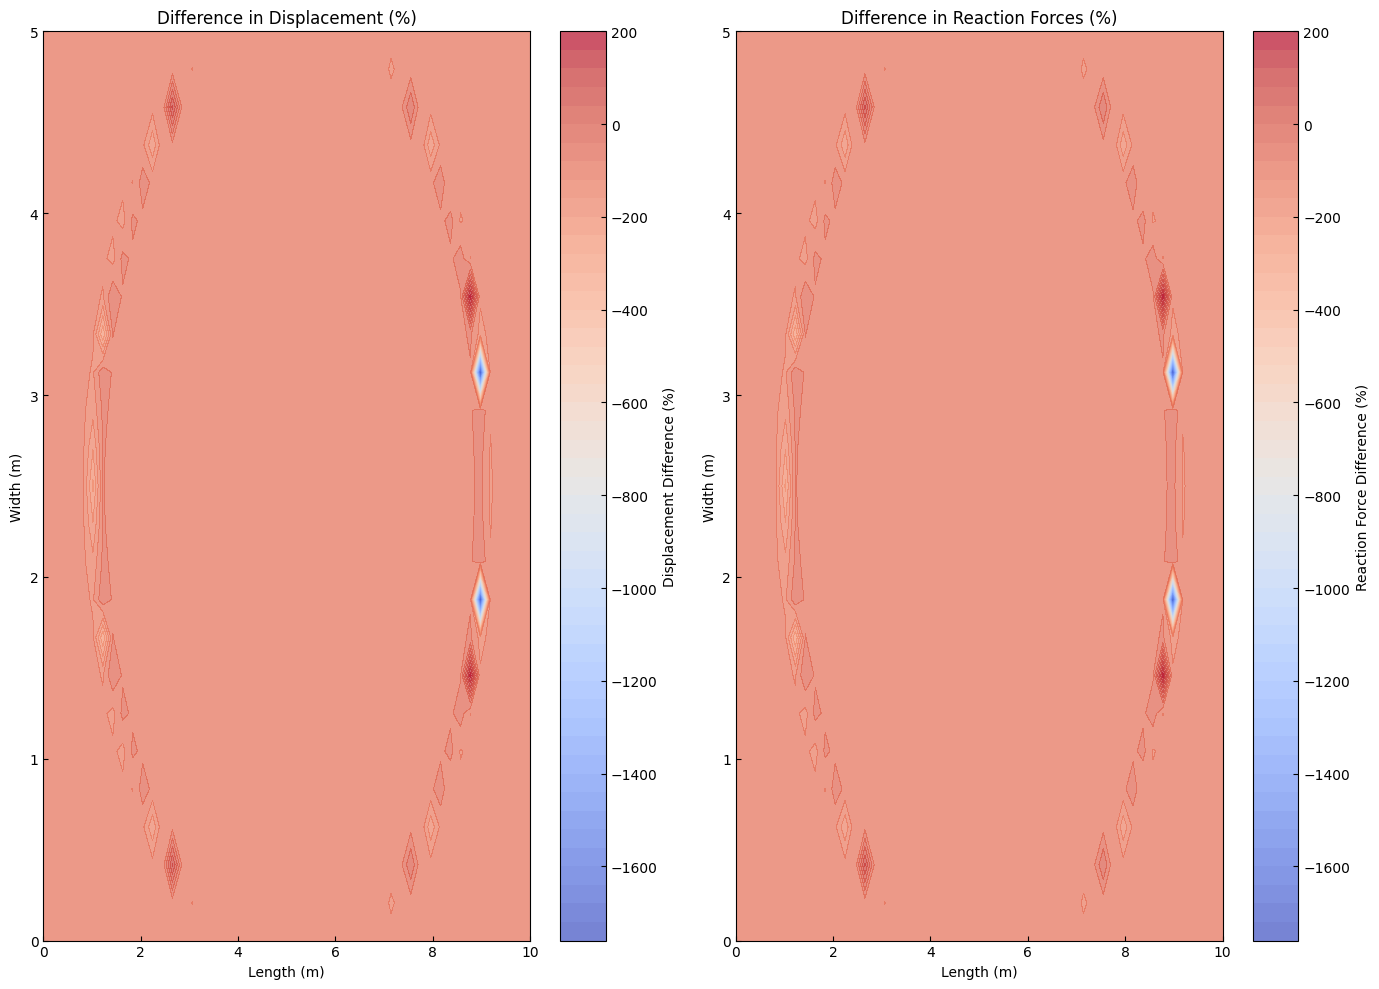

In [32]:
####################
# Plot Differences #
####################

# Calculate percentage differences
displacement_diff = np.where(displacements != 0, ((y_fd / displacements) - 1) * 100, 0)
reaction_diff = np.where(reactions_os != 0, ((reactions_fd / reactions_os) - 1) * 100, 0)

# Plot percentage differences
plt.figure(figsize=(14, 10))

# Displacement percentage difference
plt.subplot(1, 2, 1)
plt.contourf(X, Y, displacement_diff.T, levels=50, cmap="coolwarm", alpha=0.7)
plt.colorbar(label="Displacement Difference (%)")
plt.title("Difference in Displacement (%)")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")

# Reaction percentage difference
plt.subplot(1, 2, 2)
plt.contourf(X, Y, reaction_diff.T, levels=50, cmap="coolwarm", alpha=0.7)
plt.colorbar(label="Reaction Force Difference (%)")
plt.title("Difference in Reaction Forces (%)")
plt.xlabel("Length (m)")
plt.ylabel("Width (m)")

plt.tight_layout()
plt.show()
